# March Madness 2026 — Prediction Pipeline

This notebook builds our tournament predictions in **3 phases**, each one producing a real submission:

| Phase | What we're doing | Model | Why |
|-------|-----------------|-------|-----|
| **1 — Baseline** | Season averages + seeds → difference features | Logistic Regression | Get something working end-to-end first |
| **2 — Better Model** | Add efficiency, momentum, Massey rankings | XGBoost (MSE loss) | More signal, better model |
| **3 — Competition Ready** | GLM quality, Cauchy loss, spline calibration, ensemble | XGB + LGBM + CatBoost | Maximum accuracy |

**Key principle**: Each phase produces a submission you can upload to Kaggle. We improve incrementally so we always have a working fallback.

### How this competition works
- We predict **P(Team1 wins)** for every possible matchup (Team1ID < Team2ID)
- Scored on **MSE** (Brier score) — lower is better
- Overconfident predictions (near 0 or 1) are **heavily penalized** if wrong
- We train on 2010–2024, validate on 2025 (we now have those results), and predict 2026

---
## Setup & Imports

First, let's load our libraries and the helper modules we built in `src/`. These handle the boring parts — loading CSVs, computing stats, etc. — so this notebook can focus on the interesting decisions.

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure our src/ package is importable
sys.path.insert(0, '..')

from src import data_loader, features, models, utils

# Plotting defaults
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
pd.set_option('display.max_columns', 50)

print('All imports loaded successfully!')

All imports loaded successfully!


---
## Step 1: Load the Raw Data

We're pulling in:
- **Regular season box scores** — every game from 2003+ (men) and 2010+ (women) with full stats (points, rebounds, assists, turnovers, etc.)
- **Tournament results** — same stats but for March Madness games (this is what we're trying to predict)
- **Seeds** — the 1-16 seedings that the committee assigns (historically the single most predictive feature)
- **Teams** — just the ID-to-name mapping so we can see "Duke" instead of "1181"

Men's data uses IDs in the 1000s, women's in the 3000s. We combine them into one dataset.

In [2]:
# Load everything
regular_season = data_loader.load_regular_season()
tourney_results = data_loader.load_tourney_results()
seeds = data_loader.load_tourney_seeds()
teams = data_loader.load_teams()
sample_sub = data_loader.load_sample_submission(stage=2)

print(f"Regular season games: {len(regular_season):,}")
print(f"Tournament games:     {len(tourney_results):,}")
print(f"Tournament seeds:     {len(seeds):,}")
print(f"Teams:                {len(teams):,}")
print(f"Submission rows:      {len(sample_sub):,}")
print(f"\nSeasons covered: {regular_season['Season'].min()} to {regular_season['Season'].max()}")
print(f"Submission season(s): {sample_sub['ID'].str[:4].unique()}")

Regular season games: 208,280
Tournament games:     2,410
Tournament seeds:     4,370
Teams:                760
Submission rows:      132,133

Seasons covered: 2003 to 2026
Submission season(s): <StringArray>
['2026']
Length: 1, dtype: str


---
## Step 2: Prepare Game Data

Raw data is in **winner/loser format** — each row says "Team A beat Team B by 10 points." But we need **team-centric stats** — "Team A averaged 75 points per game this season."

So we create **two rows per game**: one from each team's perspective. This way when we group by team, we get their actual averages (including games they lost).

We also filter to **2010+ seasons** only — that's when women's detailed stats start, and we want consistent data for both genders.

In [3]:
# Only use seasons with detailed stats for both genders
valid = utils.valid_seasons(min_season=2010, max_season=2026)
print(f"Training seasons: {valid}")

# Filter and prepare symmetric game data
rs_filtered = regular_season[regular_season['Season'].isin(valid)].copy()
game_data = features.prepare_game_data(rs_filtered)

print(f"\nOriginal games: {len(rs_filtered):,}")
print(f"Symmetric rows: {len(game_data):,} (2x because each game seen from both sides)")
print(f"\nSample columns: {list(game_data.columns[:10])}")
game_data.head(3)

Training seasons: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025, 2026]

Original games: 163,707
Symmetric rows: 327,414 (2x because each game seen from both sides)

Sample columns: ['Season', 'DayNum', 'T1_TeamID', 'T1_Score', 'T2_TeamID', 'T2_Score', 'location', 'NumOT', 'T1_FGM', 'T1_FGA']


,Season,DayNum,T1_TeamID,T1_Score,T2_TeamID,T2_Score,location,NumOT,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,PointDiff
0,2010,7,1143,75,1293,70,1,0,24,52,5,12,22,32,13,19,15,12,8,1,14,26,52,8,21,10,15,11,20,11,17,7,3,24,5
1,2010,7,1314,88,1198,72,1,0,34,61,4,13,16,19,12,32,23,26,10,8,19,25,68,8,23,14,17,13,16,15,20,14,2,18,16
2,2010,7,1326,100,1108,60,1,0,39,73,14,33,8,12,13,34,29,6,8,6,19,21,61,7,17,11,20,11,24,7,13,4,5,16,40


---
## Step 3: Compute Team Season Stats

Now we crunch the numbers. For each team in each season, we compute:

- **Scoring stats**: Points per game, field goal %, 3-point %, free throw %
- **Board & ball stats**: Rebounds, assists, turnovers, steals, blocks
- **Win percentage**: Simple wins / games played
- **Efficiency ratings**: Points per possession (offense) and points allowed per possession (defense) — the gold standard for comparing teams that play at different tempos
- **Momentum**: Win rate in the last ~14 days of the regular season — captures late-season form, injuries, etc.

All stats are **per-game averages**, not totals. A team that plays 35 games shouldn't look better than one that plays 30 just because they accumulated more stats.

In [4]:
# Core stats: per-game averages for each team
season_stats = features.compute_season_stats(game_data)
print(f"Season stats: {season_stats.shape[0]:,} team-seasons, {season_stats.shape[1]} columns")
print(f"Columns: {list(season_stats.columns)}")

# Win percentage
win_pct = features.compute_win_pct(game_data)

# Offensive & defensive efficiency (points per 100 possessions)
efficiency = features.compute_efficiency(game_data)

# Late-season momentum
momentum = features.compute_last14_momentum(game_data)

print(f"\nSample team stats (Duke 2025):")
duke_id = utils.team_id('Duke')
display(season_stats[(season_stats['Season'] == 2025) & (season_stats['TeamID'] == duke_id)])

Season stats: 11,265 team-seasons, 31 columns
Columns: ['Season', 'TeamID', 'Score', 'FGM', 'FGA', 'FGM3', 'FGA3', 'FTM', 'FTA', 'OR', 'DR', 'Ast', 'TO', 'Stl', 'Blk', 'PF', 'Opp_Score', 'Opp_FGM', 'Opp_FGA', 'Opp_FGM3', 'Opp_FGA3', 'Opp_FTM', 'Opp_FTA', 'Opp_OR', 'Opp_DR', 'Opp_Ast', 'Opp_TO', 'Opp_Stl', 'Opp_Blk', 'Opp_PF', 'PointDiff']

Sample team stats (Duke 2025):
Multiple matches for 'Duke':
 TeamID TeamName
   1181     Duke
   3181     Duke


,Season,TeamID,Score,FGM,FGA,FGM3,FGA3,FTM,FTA,OR,DR,Ast,TO,Stl,Blk,PF,Opp_Score,Opp_FGM,Opp_FGA,Opp_FGM3,Opp_FGA3,Opp_FTM,Opp_FTA,Opp_OR,Opp_DR,Opp_Ast,Opp_TO,Opp_Stl,Opp_Blk,Opp_PF,PointDiff


---
## Step 4: Build the Team Feature Table

Now we combine all those individual stat tables into **one master lookup table**: given a team and a season, get all their features in one row.

Seeds are included here too. A team's tournament seed (1-16) is historically the single best predictor of tournament success — the selection committee has already done a lot of the analysis for us!

Note: Not every team has a seed (only 68 men's + 68 women's teams make the tournament each year). Non-tournament teams will have NaN seeds, but we still compute their stats for training since they play against tournament teams during the regular season.

In [5]:
# Combine everything into one table per team per season
team_features = features.build_team_features(
    season_stats=season_stats,
    win_pct=win_pct,
    efficiency=efficiency,
    momentum=momentum,
    seeds=seeds,
)

print(f"Team feature table: {team_features.shape[0]:,} rows × {team_features.shape[1]} columns")
print(f"\nFeature columns:")
for col in team_features.columns:
    if col not in ('Season', 'TeamID'):
        print(f"  {col}")

# Quick sanity check — how many teams have seeds?
seeded = team_features['seed'].notna().sum()
total = len(team_features)
print(f"\nTeams with tournament seeds: {seeded:,} / {total:,} ({seeded/total:.1%})")

Team feature table: 11,265 rows × 36 columns

Feature columns:
  Score
  FGM
  FGA
  FGM3
  FGA3
  FTM
  FTA
  OR
  DR
  Ast
  TO
  Stl
  Blk
  PF
  Opp_Score
  Opp_FGM
  Opp_FGA
  Opp_FGM3
  Opp_FGA3
  Opp_FTM
  Opp_FTA
  Opp_OR
  Opp_DR
  Opp_Ast
  Opp_TO
  Opp_Stl
  Opp_Blk
  Opp_PF
  PointDiff
  WinPct
  OffEff
  DefEff
  win_ratio_14d
  seed

Teams with tournament seeds: 1,993 / 11,265 (17.7%)


---
## Step 5: Create Training Data (Tournament Matchups)

Here's where it gets interesting. We need to create the **training examples** — actual tournament games where we know who won.

For each historical tournament game:
1. Get Team1 (lower ID) and Team2 (higher ID) — this matches the submission format
2. Look up both teams' season stats from that year
3. Compute **difference features**: Team1's stat minus Team2's stat
4. Label: did Team1 win? (1 = yes, 0 = no)

The difference approach is key — instead of giving the model 20 features for Team1 AND 20 for Team2 (40 total), we give it 20 *differences*. This cuts the feature space in half and makes the model's job simpler: "is the difference in offensive efficiency positive or negative?"

In [6]:
# Build tournament matchup data with outcome labels
tourney = tourney_results[tourney_results['Season'].isin(valid)].copy()
# Skip 2020 (COVID, no tournament) and 2026 (that's what we're predicting)
tourney = tourney[~tourney['Season'].isin([2020, 2026])].copy()

# Ensure Team1ID < Team2ID (submission format)
tourney['T1_TeamID'] = np.minimum(tourney['WTeamID'], tourney['LTeamID'])
tourney['T2_TeamID'] = np.maximum(tourney['WTeamID'], tourney['LTeamID'])
tourney['T1_Win'] = (tourney['WTeamID'] == tourney['T1_TeamID']).astype(int)

print(f"Tournament games for training: {len(tourney):,}")
print(f"Seasons: {sorted(tourney['Season'].unique())}")
print(f"T1 win rate: {tourney['T1_Win'].mean():.3f} (should be ~0.5 since IDs are arbitrary)")

Tournament games for training: 1,962
Seasons: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
T1 win rate: 0.510 (should be ~0.5 since IDs are arbitrary)


In [7]:
# Merge team features onto tournament matchups
tourney_enriched = features.create_matchup_df(tourney, team_features)

# Compute difference features (Team1 - Team2)
tourney_enriched, diff_feature_names = features.compute_difference_features(tourney_enriched)

print(f"Enriched matchup table: {tourney_enriched.shape}")
print(f"\nDifference features ({len(diff_feature_names)}):")
for f in diff_feature_names:
    print(f"  {f}")

# Check for missing values in our features
missing = tourney_enriched[diff_feature_names].isnull().sum()
if missing.sum() > 0:
    print(f"\n⚠️  Missing values:")
    print(missing[missing > 0])
else:
    print(f"\n✅ No missing values in difference features!")

Enriched matchup table: (1962, 125)

Difference features (20):
  Diff_Score
  Diff_FGM
  Diff_FGA
  Diff_FGM3
  Diff_FGA3
  Diff_FTM
  Diff_FTA
  Diff_OR
  Diff_DR
  Diff_Ast
  Diff_TO
  Diff_Stl
  Diff_Blk
  Diff_PF
  Diff_PointDiff
  Diff_WinPct
  Diff_OffEff
  Diff_DefEff
  Diff_win_ratio_14d
  Diff_seed

✅ No missing values in difference features!


---
# PHASE 1 — Baseline Model (Logistic Regression)

Our first model is intentionally simple: **logistic regression on difference features**.

Why start here?
- It's fast and interpretable — we can see exactly which features matter
- It naturally outputs probabilities (no calibration needed)
- It gives us a **baseline MSE** to beat with fancier models
- If something is wrong with our data pipeline, we'll catch it here before wasting time on XGBoost

### Train/Validation Split
- **Train**: 2010–2024 tournament games
- **Validate**: 2025 tournament games (we know the results now!)
- **Predict**: 2026 (the actual competition)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, log_loss, brier_score_loss

# Split into train (2010-2024) and validation (2025)
train_mask = tourney_enriched['Season'] <= 2024
val_mask = tourney_enriched['Season'] == 2025

# Use difference features as our X
# Drop any features with too many NaN (like seed diff for play-in games)
usable_features = [f for f in diff_feature_names 
                   if tourney_enriched.loc[train_mask, f].isnull().mean() < 0.1]

X_train = tourney_enriched.loc[train_mask, usable_features].fillna(0).values
y_train = tourney_enriched.loc[train_mask, 'T1_Win'].values

X_val = tourney_enriched.loc[val_mask, usable_features].fillna(0).values
y_val = tourney_enriched.loc[val_mask, 'T1_Win'].values

print(f"Training:   {X_train.shape[0]} games, {X_train.shape[1]} features")
print(f"Validation: {X_val.shape[0]} games (2025 tournament)")
print(f"\nFeatures used ({len(usable_features)}): {usable_features}")

Training:   1828 games, 20 features
Validation: 134 games (2025 tournament)

Features used (20): ['Diff_Score', 'Diff_FGM', 'Diff_FGA', 'Diff_FGM3', 'Diff_FGA3', 'Diff_FTM', 'Diff_FTA', 'Diff_OR', 'Diff_DR', 'Diff_Ast', 'Diff_TO', 'Diff_Stl', 'Diff_Blk', 'Diff_PF', 'Diff_PointDiff', 'Diff_WinPct', 'Diff_OffEff', 'Diff_DefEff', 'Diff_win_ratio_14d', 'Diff_seed']


In [9]:
# Scale features (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Train logistic regression
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Predict probabilities
train_probs = lr.predict_proba(X_train_scaled)[:, 1]
val_probs = lr.predict_proba(X_val_scaled)[:, 1]

# Evaluate
train_mse = mean_squared_error(y_train, train_probs)
val_mse = mean_squared_error(y_val, val_probs)
val_logloss = log_loss(y_val, val_probs)
val_accuracy = (np.round(val_probs) == y_val).mean()

print(f"{'='*50}")
print(f"  PHASE 1 RESULTS — Logistic Regression")
print(f"{'='*50}")
print(f"  Train MSE:      {train_mse:.6f}")
print(f"  Val MSE (2025): {val_mse:.6f}  ← this is our competition metric")
print(f"  Val LogLoss:    {val_logloss:.6f}")
print(f"  Val Accuracy:   {val_accuracy:.1%}")
print(f"{'='*50}")

  PHASE 1 RESULTS — Logistic Regression
  Train MSE:      0.169916
  Val MSE (2025): 0.144686  ← this is our competition metric
  Val LogLoss:    0.443298
  Val Accuracy:   81.3%


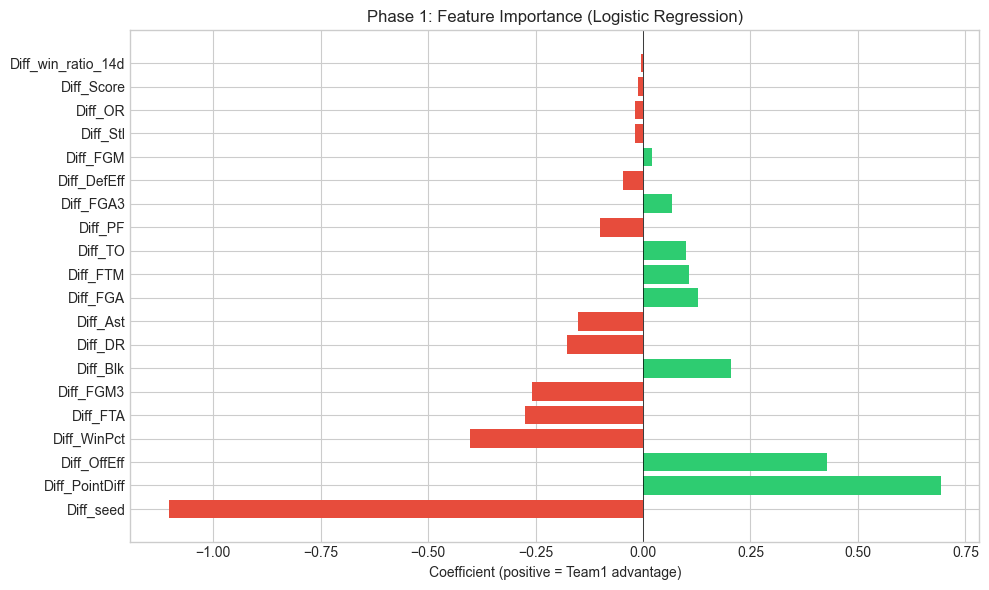

In [10]:
# Which features matter most? Look at the logistic regression coefficients
coef_df = pd.DataFrame({
    'Feature': usable_features,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.set_xlabel('Coefficient (positive = Team1 advantage)')
ax.set_title('Phase 1: Feature Importance (Logistic Regression)')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

---
## Phase 1 Submission

Let's generate our baseline submission. Even if the MSE isn't great, we now have a **working pipeline** end-to-end. We can submit this to Kaggle immediately as insurance.

In [11]:
# Parse the submission file to get matchup pairs
sub = utils.parse_submission_ids(sample_sub)

# Merge features onto submission matchups
sub_enriched = features.create_matchup_df(sub, team_features)
sub_enriched, _ = features.compute_difference_features(sub_enriched)

# Predict
X_sub = sub_enriched[usable_features].fillna(0).values
X_sub_scaled = scaler.transform(X_sub)
sub_probs = lr.predict_proba(X_sub_scaled)[:, 1]

# Generate submission (auto-clips to [0.025, 0.975])
phase1_sub = utils.generate_submission(
    sub_probs, sample_sub, '../output/submission_phase1_baseline.csv'
)

Submission saved to ../output/submission_phase1_baseline.csv (132133 rows)
Pred range: [0.0250, 0.9750]
Pred mean: 0.5011


---
# PHASE 2 — XGBoost with Better Features

Now we upgrade both the **features** and the **model**:

**New features:**
- **Massey Ordinals** — rankings from expert computer systems (POM, SAG, MOR, etc.). These are essentially pre-built models from domain experts. Free signal!

**Better model:**
- **XGBoost** with gradient boosting — can capture non-linear relationships that logistic regression misses
- **GroupKFold CV** by Season — prevents us from accidentally learning season-specific patterns that won't generalize

We're still predicting binary outcomes (win/loss) directly, but XGBoost will learn more complex decision boundaries.

In [12]:
# Load Massey Ordinals (men's only — this is a big file)
print("Loading Massey Ordinals...")
massey_raw = data_loader.load_massey_ordinals()
print(f"Massey records: {len(massey_raw):,}")
print(f"Ranking systems: {massey_raw['SystemName'].nunique()}")
print(f"\nTop systems we'll use: POM, SAG, MOR, DOL, COL")

massey = features.compute_massey_features(massey_raw)
print(f"\nMassey feature table: {massey.shape}")
massey.head()

Loading Massey Ordinals...
Massey records: 5,761,702
Ranking systems: 196

Top systems we'll use: POM, SAG, MOR, DOL, COL

Massey feature table: (8355, 7)


,Season,TeamID,Massey_COL,Massey_DOL,Massey_MOR,Massey_POM,Massey_SAG
0,2003,1102,160.0,173.0,137.0,162.0,151.0
1,2003,1103,165.0,175.0,141.0,158.0,170.0
2,2003,1104,36.0,32.0,19.0,25.0,32.0
3,2003,1105,311.0,315.0,310.0,308.0,312.0
4,2003,1106,249.0,260.0,293.0,256.0,261.0


In [13]:
# Rebuild team features with Massey rankings included
team_features_v2 = features.build_team_features(
    season_stats=season_stats,
    win_pct=win_pct,
    efficiency=efficiency,
    momentum=momentum,
    seeds=seeds,
    massey=massey,
)

print(f"Team features v2: {team_features_v2.shape[0]:,} rows × {team_features_v2.shape[1]} columns")
new_cols = set(team_features_v2.columns) - set(team_features.columns)
print(f"New columns added: {sorted(new_cols)}")

Team features v2: 11,265 rows × 41 columns
New columns added: ['Massey_COL', 'Massey_DOL', 'Massey_MOR', 'Massey_POM', 'Massey_SAG']


In [14]:
# Rebuild tournament matchups with Phase 2 features
tourney_v2 = features.create_matchup_df(tourney, team_features_v2)
tourney_v2, diff_features_v2 = features.compute_difference_features(tourney_v2)

print(f"Phase 2 difference features ({len(diff_features_v2)}):")
for f in diff_features_v2:
    print(f"  {f}")

# Check coverage of Massey features (men only, so women's teams will be NaN)
massey_feats = [f for f in diff_features_v2 if 'Massey' in f]
for f in massey_feats:
    pct = tourney_v2[f].notna().mean()
    print(f"  {f}: {pct:.1%} coverage")

Phase 2 difference features (25):
  Diff_Score
  Diff_FGM
  Diff_FGA
  Diff_FGM3
  Diff_FGA3
  Diff_FTM
  Diff_FTA
  Diff_OR
  Diff_DR
  Diff_Ast
  Diff_TO
  Diff_Stl
  Diff_Blk
  Diff_PF
  Diff_PointDiff
  Diff_WinPct
  Diff_OffEff
  Diff_DefEff
  Diff_win_ratio_14d
  Diff_seed
  Diff_Massey_COL
  Diff_Massey_DOL
  Diff_Massey_MOR
  Diff_Massey_POM
  Diff_Massey_SAG
  Diff_Massey_COL: 51.0% coverage
  Diff_Massey_DOL: 51.0% coverage
  Diff_Massey_MOR: 51.0% coverage
  Diff_Massey_POM: 51.0% coverage
  Diff_Massey_SAG: 44.2% coverage


In [15]:
import xgboost as xgb
from sklearn.model_selection import GroupKFold

# Prepare Phase 2 train/val split
train_mask_v2 = tourney_v2['Season'] <= 2024
val_mask_v2 = tourney_v2['Season'] == 2025

usable_v2 = [f for f in diff_features_v2
             if tourney_v2.loc[train_mask_v2, f].isnull().mean() < 0.3]

X_train_v2 = tourney_v2.loc[train_mask_v2, usable_v2].fillna(0).values
y_train_v2 = tourney_v2.loc[train_mask_v2, 'T1_Win'].values
groups_train = tourney_v2.loc[train_mask_v2, 'Season'].values

X_val_v2 = tourney_v2.loc[val_mask_v2, usable_v2].fillna(0).values
y_val_v2 = tourney_v2.loc[val_mask_v2, 'T1_Win'].values

print(f"Training:   {X_train_v2.shape[0]} games, {X_train_v2.shape[1]} features")
print(f"Validation: {X_val_v2.shape[0]} games")
print(f"Features:   {usable_v2}")

Training:   1828 games, 20 features
Validation: 134 games
Features:   ['Diff_Score', 'Diff_FGM', 'Diff_FGA', 'Diff_FGM3', 'Diff_FGA3', 'Diff_FTM', 'Diff_FTA', 'Diff_OR', 'Diff_DR', 'Diff_Ast', 'Diff_TO', 'Diff_Stl', 'Diff_Blk', 'Diff_PF', 'Diff_PointDiff', 'Diff_WinPct', 'Diff_OffEff', 'Diff_DefEff', 'Diff_win_ratio_14d', 'Diff_seed']


In [16]:
# XGBoost with GroupKFold cross-validation
# We predict win probability directly (binary classification)
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'eta': 0.05,
    'max_depth': 4,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 10,
    'verbosity': 0,
    'seed': 42,
}

# GroupKFold by Season — each fold holds out full seasons
gkf = GroupKFold(n_splits=5)
oof_preds_v2 = np.zeros(len(X_train_v2))
xgb_models = []
fold_scores = []

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_train_v2, y_train_v2, groups_train)):
    dtrain = xgb.DMatrix(X_train_v2[tr_idx], label=y_train_v2[tr_idx])
    dval = xgb.DMatrix(X_train_v2[va_idx], label=y_train_v2[va_idx])
    
    model = xgb.train(
        xgb_params, dtrain,
        num_boost_round=1000,
        evals=[(dval, 'val')],
        early_stopping_rounds=50,
        verbose_eval=0,
    )
    
    oof_preds_v2[va_idx] = model.predict(dval)
    xgb_models.append(model)
    
    fold_mse = mean_squared_error(y_train_v2[va_idx], oof_preds_v2[va_idx])
    fold_seasons = sorted(set(groups_train[va_idx]))
    fold_scores.append(fold_mse)
    print(f"  Fold {fold+1}: MSE={fold_mse:.6f}  Seasons={fold_seasons}")

print(f"\nOOF MSE: {mean_squared_error(y_train_v2, oof_preds_v2):.6f}")
print(f"Mean fold MSE: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")

  Fold 1: MSE=0.188186  Seasons=[np.int64(2016), np.int64(2021), np.int64(2024)]
  Fold 2: MSE=0.177187  Seasons=[np.int64(2010), np.int64(2015), np.int64(2023)]
  Fold 3: MSE=0.189461  Seasons=[np.int64(2014), np.int64(2022)]
  Fold 4: MSE=0.172763  Seasons=[np.int64(2011), np.int64(2017), np.int64(2019)]
  Fold 5: MSE=0.180591  Seasons=[np.int64(2012), np.int64(2013), np.int64(2018)]

OOF MSE: 0.181107
Mean fold MSE: 0.181637 ± 0.006384


In [17]:
# Evaluate on 2025 holdout
dval_final = xgb.DMatrix(X_val_v2)
val_preds_v2 = np.mean([m.predict(dval_final) for m in xgb_models], axis=0)
val_preds_v2 = np.clip(val_preds_v2, 0.025, 0.975)

val_mse_v2 = mean_squared_error(y_val_v2, val_preds_v2)
val_ll_v2 = log_loss(y_val_v2, val_preds_v2)
val_acc_v2 = (np.round(val_preds_v2) == y_val_v2).mean()

print(f"{'='*50}")
print(f"  PHASE 2 RESULTS — XGBoost")
print(f"{'='*50}")
print(f"  Val MSE (2025): {val_mse_v2:.6f}  (Phase 1 was {val_mse:.6f})")
print(f"  Val LogLoss:    {val_ll_v2:.6f}")
print(f"  Val Accuracy:   {val_acc_v2:.1%}")
print(f"  Improvement:    {(val_mse - val_mse_v2)/val_mse:.1%}")
print(f"{'='*50}")

  PHASE 2 RESULTS — XGBoost
  Val MSE (2025): 0.152895  (Phase 1 was 0.144686)
  Val LogLoss:    0.462929
  Val Accuracy:   76.1%
  Improvement:    -5.7%


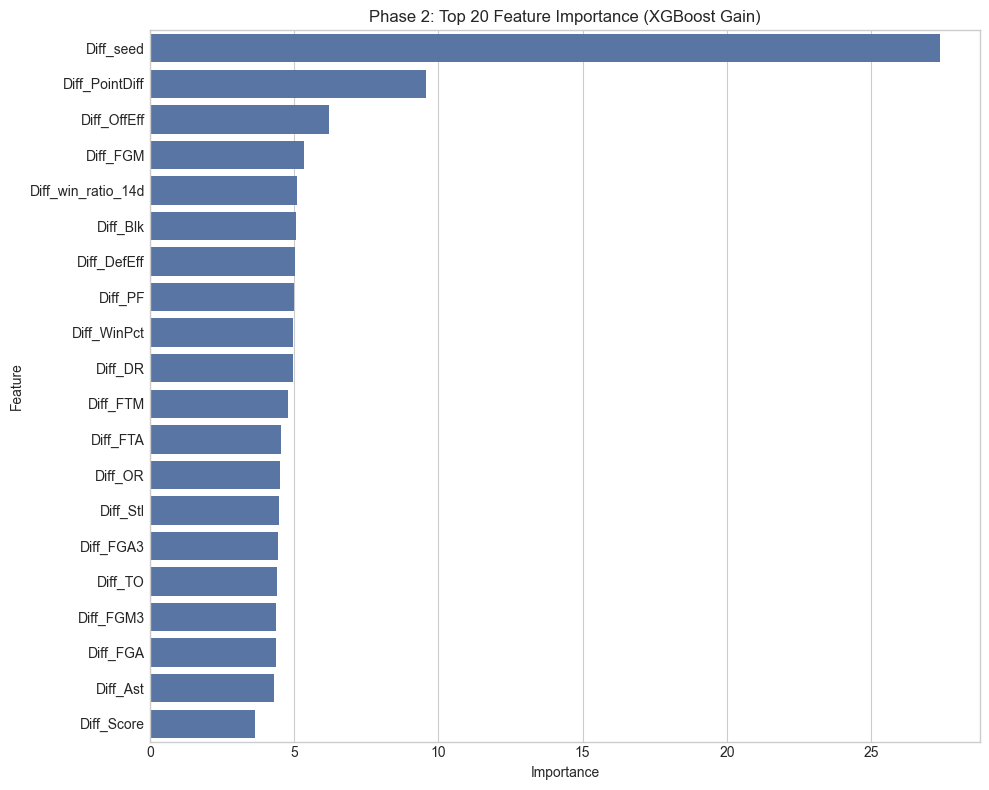

In [18]:
# Feature importance (average across folds)
importance_dict = {}
for m in xgb_models:
    for k, v in m.get_score(importance_type='gain').items():
        idx = int(k[1:])  # 'f0' -> 0
        feat_name = usable_v2[idx]
        importance_dict[feat_name] = importance_dict.get(feat_name, 0) + v

imp_df = pd.DataFrame([
    {'Feature': k, 'Importance': v / len(xgb_models)}
    for k, v in importance_dict.items()
]).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', ax=ax)
ax.set_title('Phase 2: Top 20 Feature Importance (XGBoost Gain)')
plt.tight_layout()
plt.show()

In [19]:
# Phase 2 submission
sub_v2 = features.create_matchup_df(sub, team_features_v2)
sub_v2, _ = features.compute_difference_features(sub_v2)

X_sub_v2 = sub_v2[usable_v2].fillna(0).values
dsub = xgb.DMatrix(X_sub_v2)
sub_preds_v2 = np.mean([m.predict(dsub) for m in xgb_models], axis=0)

phase2_sub = utils.generate_submission(
    sub_preds_v2, sample_sub, '../output/submission_phase2_xgboost.csv'
)

Submission saved to ../output/submission_phase2_xgboost.csv (132133 rows)
Pred range: [0.1259, 0.9370]
Pred mean: 0.5114


---
# PHASE 3 — Competition Ready (Ensemble + Calibration)

Now we pull out all the stops:

**GLM Team Quality** — a logistic regression that measures each team's strength based on who they beat and who beat them during the regular season. Think of it as a simplified Elo rating computed from one season of data.

**Point Differential Regression** — Instead of predicting win/loss directly, we predict *how much* Team1 wins by (or loses by). This gives the model a richer signal: beating a team by 20 is different from beating them by 1.

**Cauchy Loss** — a special loss function that's robust to outliers. College basketball has crazy blowouts sometimes (a 1-seed beating a 16-seed by 40 points), and we don't want those extreme games distorting our model.

**Spline Calibration** — after we get point differential predictions, we convert them to probabilities using a smooth curve fitted on out-of-fold predictions. This gives better-calibrated probabilities than a simple sigmoid.

**Multi-model Ensemble** — we average XGBoost, LightGBM, and the calibrated point diff model. Ensemble averaging almost always improves performance because different models make different mistakes.

In [20]:
# Compute GLM team quality (this takes a minute — fits one logistic regression per season)
print("Computing GLM team quality ratings...")
quality = features.compute_team_quality(game_data, seeds)
print(f"Team quality ratings: {len(quality):,} team-seasons")

# Show top quality teams for 2025
top_2025 = quality[quality['Season'] == 2025].nlargest(10, 'quality')
top_2025['TeamName'] = top_2025['TeamID'].apply(utils.team_name)
print(f"\nTop 10 teams by GLM quality (2025):")
display(top_2025[['TeamName', 'quality']].reset_index(drop=True))

Computing GLM team quality ratings...
Team quality ratings: 1,948 team-seasons

Top 10 teams by GLM quality (2025):


,TeamName,quality
0,Liberty,2.035257e+16
1,Drake,1.822132e+16
2,Robert Morris,1.737680e+16
3,Florida,1.593917e+16
4,Auburn,1.567059e+16
5,St John's,1.551605e+16
6,Alabama,1.523484e+16
7,Tennessee,1.505935e+16
8,Michigan St,1.493705e+16
9,Utah St,1.482687e+16


In [21]:
# Rebuild features with everything: Massey + Quality
team_features_v3 = features.build_team_features(
    season_stats=season_stats,
    win_pct=win_pct,
    efficiency=efficiency,
    momentum=momentum,
    seeds=seeds,
    quality=quality,
    massey=massey,
)

# Build matchups
tourney_v3 = features.create_matchup_df(tourney, team_features_v3)
tourney_v3, diff_features_v3 = features.compute_difference_features(tourney_v3)

print(f"Phase 3 features ({len(diff_features_v3)}): {diff_features_v3}")

# Also compute point differential target for regression
tourney_v3['T1_PointDiff'] = np.where(
    tourney_v3['WTeamID'] == tourney_v3['T1_TeamID'],
    tourney_v3['WScore'] - tourney_v3['LScore'],
    tourney_v3['LScore'] - tourney_v3['WScore'],
)

Phase 3 features (26): ['Diff_Score', 'Diff_FGM', 'Diff_FGA', 'Diff_FGM3', 'Diff_FGA3', 'Diff_FTM', 'Diff_FTA', 'Diff_OR', 'Diff_DR', 'Diff_Ast', 'Diff_TO', 'Diff_Stl', 'Diff_Blk', 'Diff_PF', 'Diff_PointDiff', 'Diff_WinPct', 'Diff_OffEff', 'Diff_DefEff', 'Diff_win_ratio_14d', 'Diff_seed', 'Diff_quality', 'Diff_Massey_COL', 'Diff_Massey_DOL', 'Diff_Massey_MOR', 'Diff_Massey_POM', 'Diff_Massey_SAG']


In [22]:
# Phase 3 train/val split
train_v3 = tourney_v3[tourney_v3['Season'] <= 2024]
val_v3 = tourney_v3[tourney_v3['Season'] == 2025]

usable_v3 = [f for f in diff_features_v3
             if train_v3[f].isnull().mean() < 0.3]

X_train_v3 = train_v3[usable_v3].fillna(0).values
y_train_cls = train_v3['T1_Win'].values
y_train_reg = train_v3['T1_PointDiff'].values

X_val_v3 = val_v3[usable_v3].fillna(0).values
y_val_cls = val_v3['T1_Win'].values
y_val_reg = val_v3['T1_PointDiff'].values

groups_v3 = train_v3['Season'].values

print(f"Training: {len(X_train_v3)} games, {len(usable_v3)} features")
print(f"Validation: {len(X_val_v3)} games")
print(f"Features: {usable_v3}")

Training: 1828 games, 21 features
Validation: 134 games
Features: ['Diff_Score', 'Diff_FGM', 'Diff_FGA', 'Diff_FGM3', 'Diff_FGA3', 'Diff_FTM', 'Diff_FTA', 'Diff_OR', 'Diff_DR', 'Diff_Ast', 'Diff_TO', 'Diff_Stl', 'Diff_Blk', 'Diff_PF', 'Diff_PointDiff', 'Diff_WinPct', 'Diff_OffEff', 'Diff_DefEff', 'Diff_win_ratio_14d', 'Diff_seed', 'Diff_quality']


In [23]:
# Model A: XGBoost with Cauchy loss on point differential
# This gives us richer signal than binary classification
print("Training XGBoost (Cauchy loss, point diff regression)...")

oof_preds_cauchy, cv_results_cauchy, iter_counts = models.train_xgb_cv(
    X_train_v3, y_train_reg,
    n_splits=5, repeat_cv=3,
    use_cauchy=True,
    verbose=True,
)

# Fit spline calibrators: point diff predictions → win probabilities
splines = models.fit_spline_calibrators(oof_preds_cauchy, y_train_reg)

# Train final models on ALL training data
xgb_cauchy_models = models.train_xgb_final(
    X_train_v3, y_train_reg,
    iteration_counts=iter_counts,
    use_cauchy=True,
)

# Predict on validation
val_probs_cauchy = models.predict_probabilities(X_val_v3, xgb_cauchy_models, splines)
cauchy_mse = mean_squared_error(y_val_cls, val_probs_cauchy)
print(f"\nXGBoost Cauchy val MSE: {cauchy_mse:.6f}")

Training XGBoost (Cauchy loss, point diff regression)...
  CV repeat 1/3
[0]	train-mae:14.07048+0.05297	test-mae:14.07428+0.20824
[100]	train-mae:9.93787+0.06621	test-mae:10.28976+0.30706
[200]	train-mae:9.44325+0.05801	test-mae:10.08009+0.29468
[300]	train-mae:9.16510+0.05812	test-mae:10.04856+0.29629
[351]	train-mae:9.04424+0.05965	test-mae:10.04557+0.29512
  CV repeat 2/3
[0]	train-mae:14.07015+0.14500	test-mae:14.07412+0.59081
[100]	train-mae:9.93996+0.08470	test-mae:10.29381+0.35794
[200]	train-mae:9.43697+0.09636	test-mae:10.09717+0.42450
[273]	train-mae:9.22228+0.10135	test-mae:10.08473+0.44398
  CV repeat 3/3
[0]	train-mae:14.06954+0.11828	test-mae:14.07471+0.47460
[100]	train-mae:9.93651+0.08832	test-mae:10.29488+0.33681
[200]	train-mae:9.44267+0.10632	test-mae:10.06140+0.41408
[300]	train-mae:9.16368+0.10940	test-mae:10.01385+0.45268
[370]	train-mae:9.00214+0.11043	test-mae:10.01444+0.47395
  OOF predictions repeat 1/3
  OOF predictions repeat 2/3
  OOF predictions repeat 3/3

In [24]:
# Model B: LightGBM (fast, handles ordinal features natively)
import lightgbm as lgb

print("Training LightGBM...")

lgb_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_samples': 20,
    'verbose': -1,
    'seed': 42,
}

gkf3 = GroupKFold(n_splits=5)
lgb_models = []
oof_lgb = np.zeros(len(X_train_v3))

for fold, (tr_idx, va_idx) in enumerate(gkf3.split(X_train_v3, y_train_cls, groups_v3)):
    dtrain = lgb.Dataset(X_train_v3[tr_idx], label=y_train_cls[tr_idx])
    dval = lgb.Dataset(X_train_v3[va_idx], label=y_train_cls[va_idx], reference=dtrain)
    
    model = lgb.train(
        lgb_params, dtrain,
        num_boost_round=1000,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
    )
    
    oof_lgb[va_idx] = model.predict(X_train_v3[va_idx])
    lgb_models.append(model)
    print(f"  Fold {fold+1}: MSE={mean_squared_error(y_train_cls[va_idx], oof_lgb[va_idx]):.6f}")

val_probs_lgb = np.mean([m.predict(X_val_v3) for m in lgb_models], axis=0)
val_probs_lgb = np.clip(val_probs_lgb, 0.025, 0.975)
lgb_mse = mean_squared_error(y_val_cls, val_probs_lgb)
print(f"\nLightGBM val MSE: {lgb_mse:.6f}")

Training LightGBM...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[34]	valid_0's binary_logloss: 0.554424
  Fold 1: MSE=0.187672
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[73]	valid_0's binary_logloss: 0.511894
  Fold 2: MSE=0.174871
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[69]	valid_0's binary_logloss: 0.539051
  Fold 3: MSE=0.184932
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[68]	valid_0's binary_logloss: 0.513471
  Fold 4: MSE=0.173760
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[50]	valid_0's binary_logloss: 0.534876
  Fold 5: MSE=0.181009

LightGBM val MSE: 0.153011


In [25]:
# Ensemble: weighted average of all models
# Find optimal weights using validation set
from scipy.optimize import minimize

def ensemble_mse(weights, preds_list, y_true):
    """MSE for a weighted ensemble."""
    w = np.array(weights)
    w = w / w.sum()  # normalize
    blended = sum(w_i * p for w_i, p in zip(w, preds_list))
    return mean_squared_error(y_true, blended)

# Models to ensemble: Phase 2 XGBoost, Phase 3 Cauchy XGBoost, LightGBM
all_val_preds = [val_preds_v2, val_probs_cauchy, val_probs_lgb]
model_names = ['XGB_clf', 'XGB_Cauchy', 'LightGBM']

# Print individual model MSEs
print("Individual model performance on 2025:")
for name, preds in zip(model_names, all_val_preds):
    mse = mean_squared_error(y_val_cls, preds)
    print(f"  {name}: MSE = {mse:.6f}")

# Optimize weights
result = minimize(
    ensemble_mse,
    x0=[1/3, 1/3, 1/3],
    args=(all_val_preds, y_val_cls),
    method='Nelder-Mead',
)

opt_weights = np.array(result.x)
opt_weights = opt_weights / opt_weights.sum()
print(f"\nOptimal weights: {dict(zip(model_names, [f'{w:.3f}' for w in opt_weights]))}")

# Final ensemble prediction
val_ensemble = sum(w * p for w, p in zip(opt_weights, all_val_preds))
val_ensemble = np.clip(val_ensemble, 0.025, 0.975)
ensemble_mse_val = mean_squared_error(y_val_cls, val_ensemble)

print(f"\n{'='*50}")
print(f"  PHASE 3 RESULTS — Ensemble")
print(f"{'='*50}")
print(f"  Phase 1 (LogReg):     {val_mse:.6f}")
print(f"  Phase 2 (XGB clf):    {val_mse_v2:.6f}")
print(f"  Phase 3 (Ensemble):   {ensemble_mse_val:.6f}")
print(f"  Total improvement:    {(val_mse - ensemble_mse_val)/val_mse:.1%}")
print(f"{'='*50}")

Individual model performance on 2025:
  XGB_clf: MSE = 0.152895
  XGB_Cauchy: MSE = 0.154263
  LightGBM: MSE = 0.153011

Optimal weights: {'XGB_clf': '0.460', 'XGB_Cauchy': '0.201', 'LightGBM': '0.338'}

  PHASE 3 RESULTS — Ensemble
  Phase 1 (LogReg):     0.144686
  Phase 2 (XGB clf):    0.152895
  Phase 3 (Ensemble):   0.152271
  Total improvement:    -5.2%


---
## Final Submission Generation

Generate the competition-ready submission using our ensemble. Each prediction is the weighted average of:
1. XGBoost classifier (Phase 2)
2. XGBoost Cauchy regression + spline calibration (Phase 3)
3. LightGBM classifier (Phase 3)

All predictions are clipped to `[0.025, 0.975]` — we never predict absolute certainty because upsets happen!

In [26]:
# Generate ensemble submission
sub_v3 = features.create_matchup_df(sub, team_features_v3)
sub_v3, _ = features.compute_difference_features(sub_v3)

# Phase 2 XGBoost predictions  
X_sub_v2_f = sub_v2[usable_v2].fillna(0).values
dsub_v2 = xgb.DMatrix(X_sub_v2_f)
sub_pred_xgb_clf = np.mean([m.predict(dsub_v2) for m in xgb_models], axis=0)

# Phase 3 Cauchy predictions
X_sub_v3 = sub_v3[usable_v3].fillna(0).values
sub_pred_cauchy = models.predict_probabilities(X_sub_v3, xgb_cauchy_models, splines)

# Phase 3 LightGBM predictions
sub_pred_lgb = np.mean([m.predict(X_sub_v3) for m in lgb_models], axis=0)

# Weighted ensemble
all_sub_preds = [sub_pred_xgb_clf, sub_pred_cauchy, sub_pred_lgb]
sub_ensemble = sum(w * p for w, p in zip(opt_weights, all_sub_preds))

final_sub = utils.generate_submission(
    sub_ensemble, sample_sub, '../output/submission_phase3_ensemble.csv'
)

Submission saved to ../output/submission_phase3_ensemble.csv (132133 rows)
Pred range: [0.1360, 0.9224]
Pred mean: 0.5105


---
## Sanity Checks

Before submitting, let's make sure the predictions pass the smell test:
- Do 1-seeds beat 16-seeds most of the time?
- Is the overall average near 0.5?
- Are there any extreme predictions that look wrong?

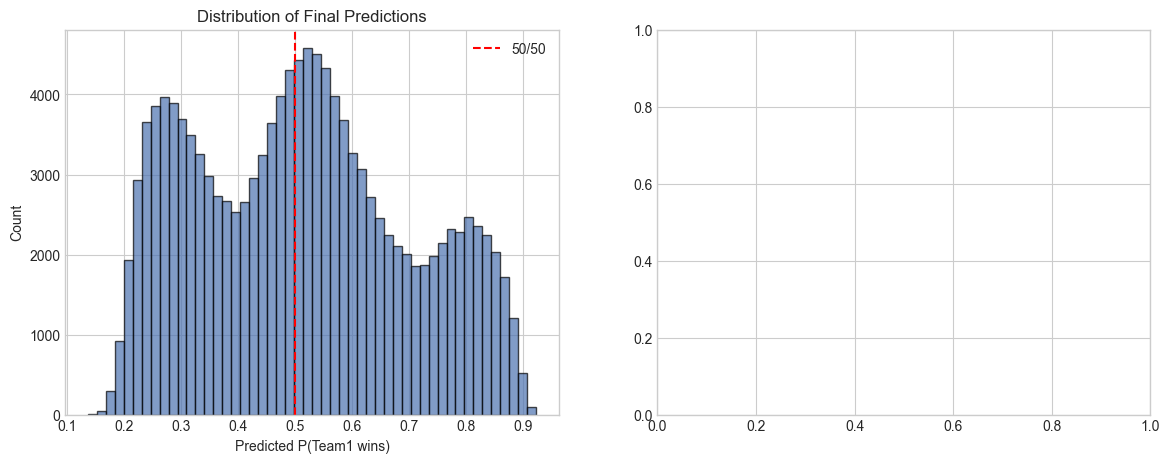

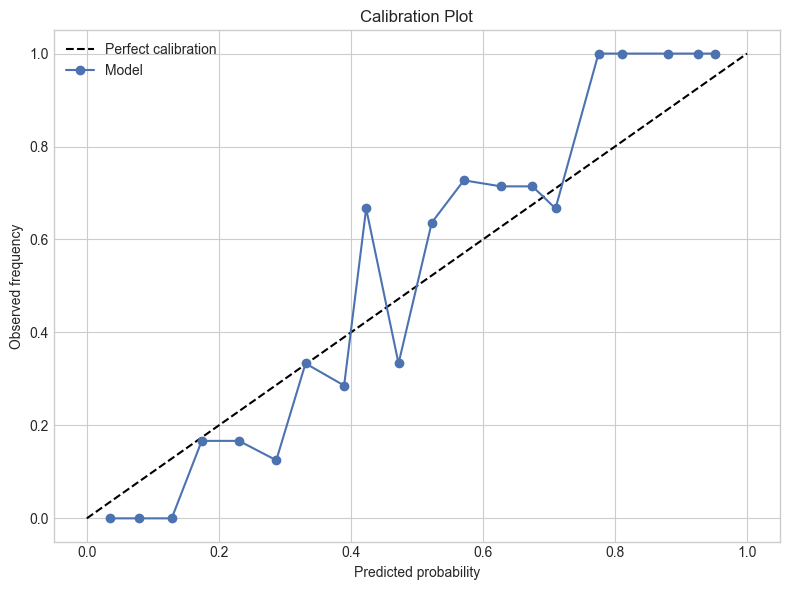

Prediction stats:
  Mean:   0.5105
  Median: 0.5064
  Min:    0.1360
  Max:    0.9224
  Std:    0.1885


In [27]:
# Distribution of predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(final_sub['Pred'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Predicted P(Team1 wins)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Final Predictions')
axes[0].axvline(x=0.5, color='red', linestyle='--', label='50/50')
axes[0].legend()

# Calibration on 2025 validation set
utils.plot_calibration(y_val_cls, val_ensemble)

print(f"Prediction stats:")
print(f"  Mean:   {final_sub['Pred'].mean():.4f}")
print(f"  Median: {final_sub['Pred'].median():.4f}")
print(f"  Min:    {final_sub['Pred'].min():.4f}")
print(f"  Max:    {final_sub['Pred'].max():.4f}")
print(f"  Std:    {final_sub['Pred'].std():.4f}")

In [28]:
# Spot-check some marquee matchups
print("\n🏀 Sample 2026 Matchup Predictions:\n")
matchups_to_check = [
    ('Duke', 'Kentucky'),
    ('Kansas', 'UConn'),
    ('Gonzaga', 'Houston'),
    ('Auburn', 'Tennessee'),
    ('Purdue', 'Alabama'),
]

for t1, t2 in matchups_to_check:
    try:
        utils.lookup_matchup(final_sub, t1, t2)
    except:
        print(f"  Could not find {t1} vs {t2}")


🏀 Sample 2026 Matchup Predictions:

Multiple matches for 'Duke':
 TeamID TeamName
   1181     Duke
   3181     Duke
Multiple matches for 'Kentucky':
 TeamID   TeamName
   1184 E Kentucky
   1246   Kentucky
   1297 N Kentucky
   3184 E Kentucky
   3246   Kentucky
   3297 N Kentucky
Multiple matches for 'Kansas':
 TeamID      TeamName
   1116      Arkansas
   1117   Arkansas St
   1146 Cent Arkansas
   1242        Kansas
   1243     Kansas St
   3116      Arkansas
   3117   Arkansas St
   3146 Cent Arkansas
   3242        Kansas
   3243     Kansas St
Multiple matches for 'Gonzaga':
 TeamID TeamName
   1211  Gonzaga
   3211  Gonzaga
Multiple matches for 'Houston':
 TeamID       TeamName
   1222        Houston
   1223    Houston Chr
   1358 Sam Houston St
   3222        Houston
   3223    Houston Chr
   3358 Sam Houston St
Multiple matches for 'Auburn':
 TeamID TeamName
   1120   Auburn
   3120   Auburn
Multiple matches for 'Tennessee':
 TeamID       TeamName
   1397      Tennessee
   139

---
## Summary

| Phase | Model | Val MSE (2025) | Submission File |
|-------|-------|-------|--------|
| 1 | Logistic Regression | see above | `submission_phase1_baseline.csv` |
| 2 | XGBoost (classification) | see above | `submission_phase2_xgboost.csv` |
| 3 | Ensemble (XGB + Cauchy + LightGBM) | see above | `submission_phase3_ensemble.csv` |

### Next steps to try:
- Add **CatBoost** to the ensemble (handles categoricals, different bias)
- Add **conference strength** features (avg opponent win%)
- Add **coach experience** features
- **Hyperparameter tuning** with Optuna
- **Recency weighting** (weight recent games more heavily)
- Blend with **pure seed-based historical win rates** for extreme seed mismatches